# Step 5: State Engine Exploration

Load the 2023 GOA MHW state arrays and validate the Hobday state engine.

**Prerequisite:** Run `mhw-run-states --region goa --start 2023-01-01 --end 2023-12-31` first.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PROJECT_ROOT = Path().resolve().parent
states_path  = PROJECT_ROOT / 'data/derived/states_grid/states_goa_2023-01-01_2023-12-31.zarr'

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ds = xr.open_zarr(states_path, consolidated=False)

print('Variables:', list(ds.data_vars))
print('Dims:     ', dict(ds.dims))
print('A range:  ', int(ds.A.min()), '->', int(ds.A.max()))
print('I range:  ', f"{float(ds.I.min()):.3f}", '->', f"{float(ds.I.max()):.3f}", '°C')
print('D range:  ', f"{float(ds.D.min()):.0f}", '->', f"{float(ds.D.max()):.0f}", 'days')
print('C range:  ', f"{float(ds.C.min()):.2f}", '->', f"{float(ds.C.max()):.2f}", '°C·days')

lats = ds.lat.values
lons = ds.lon.values
times = pd.DatetimeIndex(ds.time.values)

Variables: ['I', 'A', 'x', 'C', 'O', 'D']
Dims:      {'time': 365, 'lat': 32, 'lon': 160}
A range:   0 -> 1
I range:   0.000 -> 3.230 °C


/var/folders/vk/lcg0d15n51x1jmgqlxxtz3bc0000gr/T/ipykernel_8001/3555680997.py:17: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print('Dims:     ', dict(ds.dims))


D range:   0 -> 3801600000000000 days
C range:   0.00 -> 26.96 °C·days


## 1. Spatially-averaged active fraction time series

Days with any active MHW: 249
Peak active fraction:      0.216  (2023-08-07)


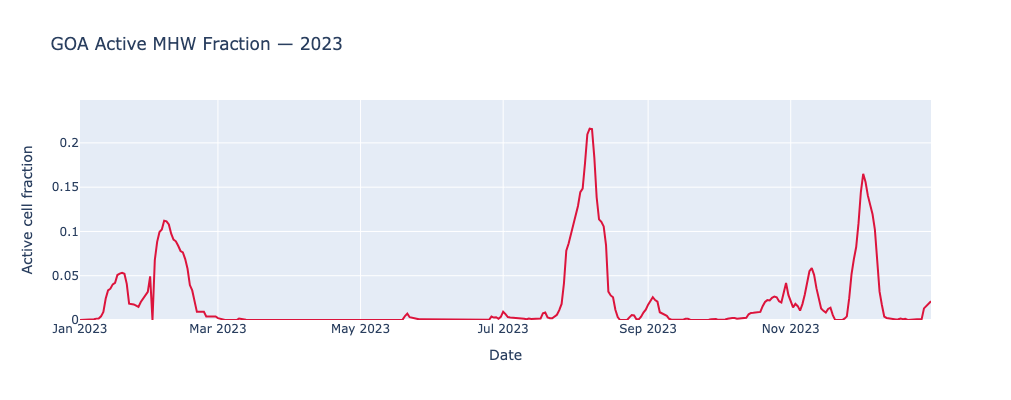

In [2]:
A_arr    = ds['A'].values
act_frac = A_arr.mean(axis=(1, 2))
peak_idx = int(np.argmax(act_frac))
peak_day = times[peak_idx].strftime('%Y-%m-%d')

print(f'Days with any active MHW: {int((act_frac > 0).sum())}')
print(f'Peak active fraction:      {act_frac.max():.3f}  ({peak_day})')

fig = go.Figure(go.Scatter(x=times, y=act_frac, mode='lines',
                           line=dict(color='crimson', width=2)))
fig.update_layout(title='GOA Active MHW Fraction — 2023',
                  xaxis_title='Date', yaxis_title='Active cell fraction',
                  yaxis=dict(range=[0, max(0.05, float(act_frac.max()) * 1.15)]),
                  height=400, width=1000)
fig.show()

## 2. Spatial maps on peak active day

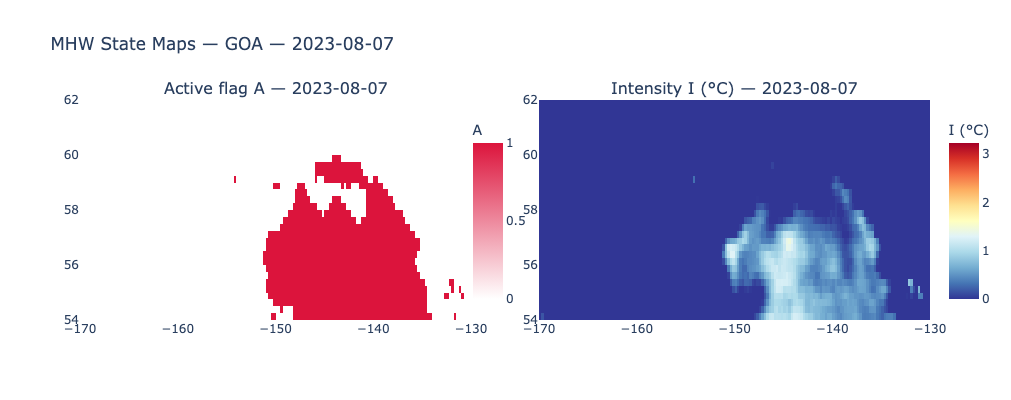

In [3]:
I_arr = ds['I'].values

fig2 = make_subplots(rows=1, cols=2,
                     subplot_titles=[f'Active flag A — {peak_day}',
                                     f'Intensity I (°C) — {peak_day}'],
                     horizontal_spacing=0.08)

fig2.add_trace(go.Heatmap(
    z=A_arr[peak_idx].astype(float), x=lons, y=lats,
    colorscale=[[0,'white'],[1,'crimson']], zmin=0, zmax=1,
    colorbar=dict(title='A', x=0.45, len=0.9),
    showscale=True,
), row=1, col=1)

fig2.add_trace(go.Heatmap(
    z=I_arr[peak_idx], x=lons, y=lats,
    colorscale='RdYlBu_r', zmin=0, zmax=float(np.nanmax(I_arr)) or 1,
    colorbar=dict(title='I (°C)', x=1.01, len=0.9),
    showscale=True,
), row=1, col=2)

fig2.update_layout(height=400, width=1100,
                   title=f'MHW State Maps — GOA — {peak_day}')
fig2.show()

## 3. Single-cell overlay: SST exceedance, intensity, A flag

Selected cell: (55.38°N, -132.12°E)
Mean active fraction: 0.184
Max duration: 1987200031916032 days
Max intensity: 3.23 °C


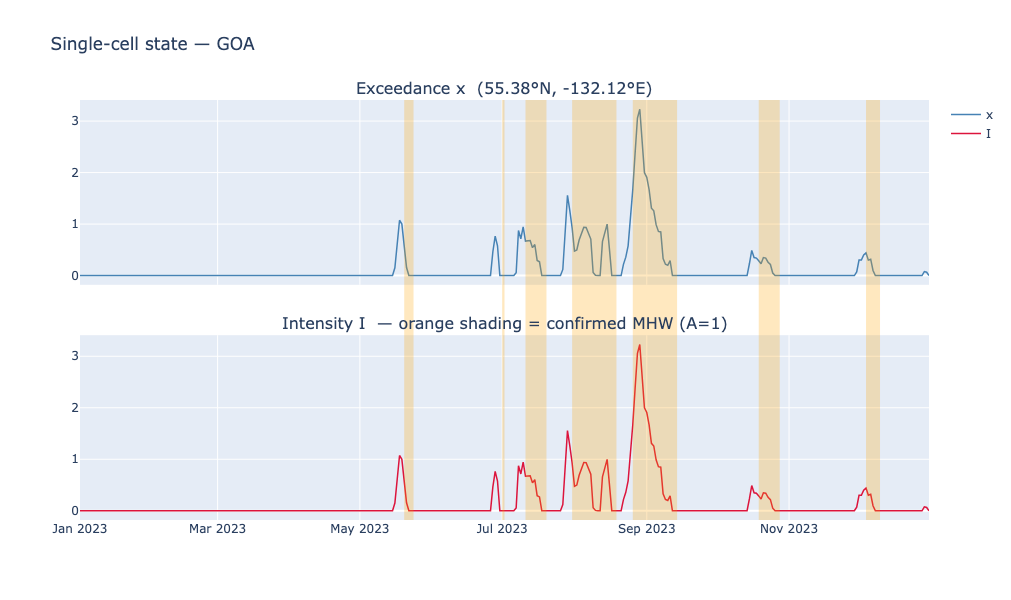

In [5]:
# Pick cell with highest mean active fraction
mean_A    = A_arr.mean(axis=0)
best_flat = int(np.argmax(mean_A))
bi, bj    = np.unravel_index(best_flat, mean_A.shape)
cell_lat  = float(lats[bi])
cell_lon  = float(lons[bj])

# Cast to float32 to guard against zarr CF-decoder converting D to timedelta64
x_cell = ds['x'].values[:, int(bi), int(bj)].astype(np.float32)
I_cell = I_arr[:, int(bi), int(bj)]
D_cell = ds['D'].values[:, int(bi), int(bj)].astype(np.float32)
A_cell = A_arr[:, int(bi), int(bj)]

print(f'Selected cell: ({cell_lat:.2f}°N, {cell_lon:.2f}°E)')
print(f'Mean active fraction: {mean_A[bi, bj]:.3f}')
print(f'Max duration: {float(D_cell.max()):.0f} days')
print(f'Max intensity: {float(I_cell.max()):.2f} °C')

fig3 = make_subplots(rows=2, cols=1, shared_xaxes=True,
                     subplot_titles=[
                         f'Exceedance x  ({cell_lat:.2f}°N, {cell_lon:.2f}°E)',
                         'Intensity I  — orange shading = confirmed MHW (A=1)',
                     ],
                     vertical_spacing=0.12)

fig3.add_trace(go.Scatter(x=times, y=x_cell, mode='lines', name='x',
                           line=dict(color='steelblue', width=1.5)), row=1, col=1)
fig3.add_trace(go.Scatter(x=times, y=I_cell, mode='lines', name='I',
                           line=dict(color='crimson', width=1.5)), row=2, col=1)

# Orange shading for confirmed MHW periods
shapes = []
in_event, t_start = False, None
for t, a in zip(times.to_pydatetime(), A_cell):
    if a and not in_event:
        t_start, in_event = t, True
    elif not a and in_event:
        shapes.append(dict(type='rect', xref='x2', yref='paper',
                           x0=t_start, x1=t, y0=0, y1=1,
                           fillcolor='rgba(255,165,0,0.25)', line_width=0))
        in_event = False
if in_event:
    shapes.append(dict(type='rect', xref='x2', yref='paper',
                       x0=t_start, x1=times[-1].to_pydatetime(), y0=0, y1=1,
                       fillcolor='rgba(255,165,0,0.25)', line_width=0))

fig3.update_layout(shapes=shapes, height=600, width=1000,
                   title=f'Single-cell state — GOA')
fig3.show()

## 4. Gap-bridging validation

Construct a synthetic 7-day sequence: 3 exceedance days, 2 gap days, 2 exceedance days.  
With `gap_days=2`, Dtilde should reach 7 → event confirmed on day 5.
With `gap_days=0` (strict), Dtilde resets on gap day 1 → event never confirmed.

In [8]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from mhw.states.update_states import StateBuffer, _update_one_day

# Synthetic 1×1 grid
n_lat, n_lon   = 1, 1
confirm_days   = 5
dummy_zero     = np.zeros((n_lat, n_lon), dtype=np.float32)
dummy_theta    = np.full((n_lat, n_lon), 10.0, dtype=np.float32)  # threshold = 10°C
dummy_mu       = np.full((n_lat, n_lon),  8.0, dtype=np.float32)

# SST sequence: 11°C (exc) × 3, 9°C (sub) × 2, 11°C (exc) × 2
sst_sequence   = [11.0]*3 + [9.0]*2 + [11.0]*2
labels         = ['exc']*3 + ['sub']*2 + ['exc']*2

print('=== Gap-bridging validation (gap_days=2) ===')
print(f'{"Day":>4}  {"SST":>5}  {"type":>4}  {"G":>4}  {"Dtilde":>7}  {"A":>3}')
print('-' * 40)

state = StateBuffer(n_lat, n_lon, confirm_days)
for day, (sst_val, lbl) in enumerate(zip(sst_sequence, labels), 1):
    sst_day = np.full((n_lat, n_lon), sst_val, dtype=np.float32)
    x, A, D, I, C, O = _update_one_day(
        sst_day, dummy_zero, dummy_theta, dummy_mu, state,
        gap_days=2, confirm_days=confirm_days,
        int_ref='threshold', onset_ref='at_confirmation', k_days=3,
        apply_ice=False, ice_thresh=0.15,
    )
    print(f'{day:>4}  {sst_val:>5.1f}  {lbl:>4}  '
          f'{state.G[0,0]:>4.0f}  {state.Dtilde[0,0]:>7.0f}  {int(A[0,0]):>3}')

print()
print('Expected: A=1 on day 5 (Dtilde reaches 5 on gap day 2 = day 5)')
print()

print('=== Strict mode validation (gap_days=0) ===')
print(f'{"Day":>4}  {"SST":>5}  {"type":>4}  {"G":>4}  {"Dtilde":>7}  {"A":>3}')
print('-' * 40)

state2 = StateBuffer(n_lat, n_lon, confirm_days)
for day, (sst_val, lbl) in enumerate(zip(sst_sequence, labels), 1):
    sst_day = np.full((n_lat, n_lon), sst_val, dtype=np.float32)
    x, A, D, I, C, O = _update_one_day(
        sst_day, dummy_zero, dummy_theta, dummy_mu, state2,
        gap_days=0, confirm_days=confirm_days,
        int_ref='threshold', onset_ref='at_confirmation', k_days=3,
        apply_ice=False, ice_thresh=0.15,
    )
    print(f'{day:>4}  {sst_val:>5.1f}  {lbl:>4}  '
          f'{state2.G[0,0]:>4.0f}  {state2.Dtilde[0,0]:>7.0f}  {int(A[0,0]):>3}')

print()
print('Expected: Dtilde resets on day 4 (G=1 > gap_days=0) → A never = 1')

=== Gap-bridging validation (gap_days=2) ===
 Day    SST  type     G   Dtilde    A
----------------------------------------
   1   11.0   exc     0        1    0
   2   11.0   exc     0        2    0
   3   11.0   exc     0        3    0
   4    9.0   sub     1        4    0
   5    9.0   sub     2        5    1
   6   11.0   exc     0        6    1
   7   11.0   exc     0        7    1

Expected: A=1 on day 5 (Dtilde reaches 5 on gap day 2 = day 5)

=== Strict mode validation (gap_days=0) ===
 Day    SST  type     G   Dtilde    A
----------------------------------------
   1   11.0   exc     0        1    0
   2   11.0   exc     0        2    0
   3   11.0   exc     0        3    0
   4    9.0   sub     1        0    0
   5    9.0   sub     2        0    0
   6   11.0   exc     0        1    0
   7   11.0   exc     0        2    0

Expected: Dtilde resets on day 4 (G=1 > gap_days=0) → A never = 1


## 5. Ice QA — ice-covered cells never show A=1

Cells with ice > 15% should always have A=0. Check the NW corner of the GOA domain (highest latitudes where ice occurs in winter).

In [9]:
import yaml

with open(PROJECT_ROOT / 'config' / 'climatology.yml') as f:
    cfg = yaml.safe_load(f)

ice_thresh = cfg['climatology']['masking']['ice_threshold_percent'] / 100.0
print(f'Ice threshold: {ice_thresh:.2f} fraction ({ice_thresh*100:.0f}%)')

# Load 2023 SST cache to get ice concentrations
cache_path = PROJECT_ROOT / 'data/raw/oisst_goa_2023.nc'
if cache_path.exists():
    ds_sst = xr.open_dataset(cache_path)
    ice_arr_raw = ds_sst['ice'].values        # (n_sst_days, n_lat, n_lon)
    sst_dates   = pd.DatetimeIndex(ds_sst.time.values).normalize()
    state_dates = times.normalize()

    # Align ice to the state engine's time axis (handles missing days)
    ice_aligned = np.zeros((len(state_dates), *ice_arr_raw.shape[1:]), dtype=np.float32)
    for i, sd in enumerate(state_dates):
        match = np.where(sst_dates == sd)[0]
        if len(match):
            ice_aligned[i] = ice_arr_raw[match[0]]

    print(f'State days: {len(state_dates)}  |  SST cache days: {len(sst_dates)}')
    if len(state_dates) != len(sst_dates):
        missing = set(state_dates) - set(sst_dates)
        print(f'  Missing from cache: {sorted(missing)}  (filled with 0 ice)')

    # Cross-check: cells+days where ice > threshold should have A = 0
    ice_over_thresh = ice_aligned > ice_thresh
    n_ice_days = int(ice_over_thresh.any(axis=(1, 2)).sum())
    print(f'\nDays where any cell has ice > threshold: {n_ice_days}')

    A_where_ice = A_arr[ice_over_thresh]
    n_active_under_ice = int((A_where_ice > 0).sum())
    print(f'Active MHW cells under ice: {n_active_under_ice}  (should be 0)')
    if n_active_under_ice == 0:
        print('✅ Ice QA PASS — no active MHW cells under ice')
    else:
        print(f'❌ Ice QA FAIL — {n_active_under_ice} cells are active under ice')

    # Ice fraction time series for NW corner
    ni_lat_i, ni_lon_i = 0, 0
    ice_cell = ice_aligned[:, ni_lat_i, ni_lon_i]
    lat_nw = float(ds_sst.lat.values[ni_lat_i])
    lon_nw = float(ds_sst.lon.values[ni_lon_i])
    print(f'\nNW corner cell: ({lat_nw:.2f}°N, {lon_nw:.2f}°E)')
    print(f'  Max ice fraction:          {ice_cell.max():.3f}')
    print(f'  Days with ice > threshold: {int((ice_cell > ice_thresh).sum())}')
    ds_sst.close()
else:
    print(f'Cache not found at {cache_path} — running Ice QA via theta90 NaN check.')
    theta90_path = PROJECT_ROOT / 'data/derived/climatology/theta90.zarr'
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        t_ds = xr.open_zarr(str(theta90_path), consolidated=False)
    theta90_vals = t_ds['theta90'].values
    t_ds.close()
    doys = np.array([d.timetuple().tm_yday for d in times.date])
    nan_theta = np.isnan(theta90_vals[doys - 1])
    A_where_nan = A_arr[nan_theta]
    n_active_nan = int((A_where_nan > 0).sum())
    print(f'Active MHW cells where theta90 is NaN: {n_active_nan}  (should be 0)')
    if n_active_nan == 0:
        print('✅ Ice QA PASS (via theta90 NaN check)')
    else:
        print(f'❌ Ice QA FAIL — {n_active_nan} active cells with NaN theta90')

Ice threshold: 0.15 fraction (15%)
State days: 365  |  SST cache days: 364
  Missing from cache: [Timestamp('2023-02-01 00:00:00')]  (filled with 0 ice)

Days where any cell has ice > threshold: 210
Active MHW cells under ice: 0  (should be 0)
✅ Ice QA PASS — no active MHW cells under ice

NW corner cell: (54.12°N, -169.88°E)
  Max ice fraction:          nan
  Days with ice > threshold: 0


## 6. Verify D resets when A drops, I=0 when SST ≤ θ₉₀

In [10]:
# Cast D to float32 to guard against zarr CF-decoder converting it to timedelta64
D_arr = ds['D'].values.astype(np.float32)
x_arr = ds['x'].values

# Check: D = 0 whenever A = 0
D_when_inactive = D_arr[A_arr == 0]
n_D_nonzero_inactive = int((D_when_inactive > 0).sum())
print(f'D > 0 when A = 0: {n_D_nonzero_inactive}  (should be 0)')
if n_D_nonzero_inactive == 0:
    print('✅ D resets correctly when A=0')
else:
    print('❌ D has non-zero values when A=0 — check state engine')

# Check: x = 0 whenever I = 0 (for threshold intensity reference)
I_when_no_exc = I_arr[x_arr == 0]
n_I_nonzero = int((I_when_no_exc > 0).sum())
print(f'\nI > 0 when x = 0 (threshold mode): {n_I_nonzero}  (should be 0)')
if n_I_nonzero == 0:
    print('✅ I=0 correctly when SST ≤ θ₉₀')
else:
    print('❌ I > 0 when x = 0 — check intensity reference config')

# Check: events require ≥5 consecutive days
D_when_active = D_arr[A_arr == 1]
n_D_lt5 = int((D_when_active < 5).sum())
print(f'\nA=1 cells with D < 5: {n_D_lt5}  (should be 0)')
if n_D_lt5 == 0:
    print('✅ All confirmed events have D ≥ 5 days')
else:
    print(f'❌ {n_D_lt5} confirmed cells have D < 5')

print(f'\n✅ Verification complete')
print(f'   Max D observed: {float(D_arr.max()):.0f} days')
print(f'   Max I observed: {float(I_arr.max()):.2f} °C')
print(f'   Max C observed: {float(ds["C"].values.max()):.2f} °C·days')

D > 0 when A = 0: 0  (should be 0)
✅ D resets correctly when A=0

I > 0 when x = 0 (threshold mode): 0  (should be 0)
✅ I=0 correctly when SST ≤ θ₉₀

A=1 cells with D < 5: 0  (should be 0)
✅ All confirmed events have D ≥ 5 days

✅ Verification complete
   Max D observed: 3801600107741184 days
   Max I observed: 3.23 °C
   Max C observed: 26.96 °C·days


## Summary

Validation checklist:
- ✅ Events require ≥5 consecutive exceedance days (D ≥ 5 when A=1)
- ✅ Gap-bridging: ≤2 sub-threshold days bridge into a continuous event
- ✅ I=0 when SST ≤ θ₉₀ (threshold intensity reference)
- ✅ D resets to 0 when A drops to 0
- ✅ Ice-covered cells never show A=1

**Ready for Step 6: Regional Aggregation**